# Coarse-to-Fine Breast Lesion Segmentation in Ultrasound Images: A Detection-Guided Two-Stage Framework - Evaluation Pipeline

In [67]:
%matplotlib inline

import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import albumentations as A
import matplotlib.pyplot as plt
import pytorch_lightning as pl
import segmentation_models_pytorch as smp
from skimage.filters import threshold_otsu
from ultralytics import YOLO
from glob import glob
from pathlib import Path

In [68]:
# ── PATH CONFIGURATION ──────────────────────────────────────────────────────
BASE_DIR = './'
DATA_DIR = os.path.join(BASE_DIR, 'data')
MODELS_DIR = os.path.join(BASE_DIR, 'weights')


print('DATA_DIR  :', DATA_DIR)
print('MODELS_DIR:', MODELS_DIR)

DATA_DIR  : ./data
MODELS_DIR: ./weights


In [69]:
# ── PIPELINE CONFIGURATION ──────────────────────────────────────────────────

# Dataset
dataset = "UDIAT"   # UDIAT | BUSI | BUSBRAr | custom
datasrcs = "UDIAT" if dataset == "custom" else dataset
datasrcs_crop = f"{datasrcs}_crop"

img_ext       = ".png"
mask_ext      = ".png" 
mask_suffix   = ""                    

# Segmentation model
method      = "Unet"                  # Unet | UnetPlusPlus | DeepLabV3Plus
backbone    = "resnet18"              
OUT_CLASSES = 1

# YOLO
YOLO_MODEL = "yolov8s"               # yolov3-tinyu | yolov8s | yolo12s | 
YOLO_CONF  = 0.15                     # detection confidence threshold 0.15
YOLO_IOU   = 0.45                     # NMS IoU threshold 0.45

# Derived paths — best checkpoints saved by ModelCheckpoint during training
seg_crop_weights_path = os.path.join(MODELS_DIR, "best__{}__{}__{}.ckpt".format(method, backbone, datasrcs_crop))
seg_weights_path      = os.path.join(MODELS_DIR, "best__{}__{}__{}.ckpt".format(method, backbone, datasrcs))
yolo_weights_path     = os.path.join(MODELS_DIR, "best__{}__{}.pt".format(YOLO_MODEL, datasrcs))

print(f"Seg crop weights : {seg_crop_weights_path}")
print(f"Seg weights      : {seg_weights_path}")
print(f"YOLO weights     : {yolo_weights_path}")
print(f"Seg crop weights exist : {os.path.exists(seg_crop_weights_path)}")
print(f"Seg weights exist      : {os.path.exists(seg_weights_path)}")
print(f"YOLO weights exist     : {os.path.exists(yolo_weights_path)}")

Seg crop weights : ./weights/best__Unet__resnet18__UDIAT_crop.ckpt
Seg weights      : ./weights/best__Unet__resnet18__UDIAT.ckpt
YOLO weights     : ./weights/best__yolov8s__UDIAT.pt
Seg crop weights exist : True
Seg weights exist      : True
YOLO weights exist     : True


In [70]:
def read_file_to_list(file_path: str) -> list[str]:
    try:
        with open(file_path) as fh:
            return fh.read().splitlines()
    except FileNotFoundError:
        print(f"Error: file not found — {file_path}")
        return []


def get_validation_augmentation(img_size: int = 512) -> A.Compose:
    return A.Compose([A.Resize(height=img_size, width=img_size)])


def otsu_threshold(prob_map: np.ndarray) -> np.ndarray:
    """Binarise *prob_map* using Otsu's method.

    Falls back to 0.5 when the map is flat (all values identical),
    which would cause threshold_otsu to raise a ValueError.
    """
    thresh = threshold_otsu(prob_map) if prob_map.min() != prob_map.max() else 0.5
    return (prob_map > thresh).astype(np.uint8)

In [71]:
def convert_bn_to_gn(module: nn.Module, max_groups: int = 32) -> None:
    """Recursively replace every BatchNorm2d in *module* with GroupNorm.

    Mirrors the training notebook exactly.
    """
    for name, child in module.named_children():
        if isinstance(child, nn.BatchNorm2d):
            num_channels = child.num_features
            num_groups   = next(
                g for g in range(max_groups, 0, -1)
                if num_channels % g == 0
            )
            setattr(module, name, nn.GroupNorm(num_groups, num_channels))
        else:
            convert_bn_to_gn(child, max_groups)

In [72]:
class SegmentationModel(pl.LightningModule):
    """Inference-time wrapper — mirrors the training notebook exactly."""

    def __init__(self, arch: str, encoder_name: str, in_channels: int, out_classes: int, **kwargs):
        super().__init__()
        self.model = smp.create_model(
            arch,
            encoder_name=encoder_name,
            in_channels=in_channels,
            classes=out_classes,
            **kwargs,
        )
        # Replace BN with GroupNorm for DeepLabV3+ — must match training notebook
        if arch == "DeepLabV3Plus":
            convert_bn_to_gn(self.model)

        # Register ImageNet normalisation constants as non-trainable buffers
        params = smp.encoders.get_preprocessing_params(encoder_name)
        self.register_buffer("mean", torch.tensor(params["mean"]).view(1, 3, 1, 1))
        self.register_buffer("std",  torch.tensor(params["std"]).view(1, 3, 1, 1))
        self.loss_fn = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=True)

    def forward(self, image: torch.Tensor) -> torch.Tensor:
        return self.model((image - self.mean) / self.std)

In [73]:
# ── Load segmentation model (full image — fallback for missed detections) ────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seg_model = SegmentationModel(method, backbone, in_channels=3, out_classes=OUT_CLASSES)
ckpt = torch.load(seg_weights_path, weights_only=True, map_location=device)
seg_model.load_state_dict(ckpt["state_dict"] if "state_dict" in ckpt else ckpt)
seg_model.eval()
seg_model = seg_model.to(device)
print(f"Full-image seg model loaded on {device}: {method} | {datasrcs}")

# ── Load segmentation model (crop — used when YOLO detects) ─────────────────
seg_crop_model = SegmentationModel(method, backbone, in_channels=3, out_classes=OUT_CLASSES)
ckpt = torch.load(seg_crop_weights_path, weights_only=True, map_location=device)
seg_crop_model.load_state_dict(ckpt["state_dict"] if "state_dict" in ckpt else ckpt)
seg_crop_model.eval()
seg_crop_model = seg_crop_model.to(device)
print(f"Crop seg model loaded on {device}: {method} | {datasrcs_crop}")

# ── Load YOLO model ──────────────────────────────────────────────────────────
yolo_model = YOLO(yolo_weights_path)
print(f"YOLO model loaded: {YOLO_MODEL}")

print(f"\nWeights exist check:")
print(f"  seg (full)  : {os.path.exists(seg_weights_path)}")
print(f"  seg (crop)  : {os.path.exists(seg_crop_weights_path)}")
print(f"  YOLO        : {os.path.exists(yolo_weights_path)}")

Full-image seg model loaded on cpu: Unet | UDIAT
Crop seg model loaded on cpu: Unet | UDIAT_crop
YOLO model loaded: yolov8s

Weights exist check:
  seg (full)  : True
  seg (crop)  : True
  YOLO        : True


## Visualization

In [74]:
BOX_MARGIN_PX = None          # e.g., 8 pixels around the mask bbox (recommended)
BOX_MARGIN_FRAC = 0.01     # e.g., 2% of image size (used only if BOX_MARGIN_PX is None)

# If your masks are very faint/noisy, optionally threshold them (0 means use >0)
MASK_THRESH = 0            # e.g., set to 127 for strict binary masks

def mask_to_yolo_box(mask_path: Path, img_wh: tuple[int, int]) -> tuple[float, float, float, float] | None:
    """
    Convert a (binary-ish) mask into a single YOLO bbox with margin.
    Returns (xc, yc, w, h) normalized or None if mask empty.
    """
    m = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if m is None:
        raise FileNotFoundError(f"Mask not readable: {mask_path}")

    # ensure mask size matches image if needed (sometimes masks differ slightly)
    W, H = img_wh
    if m.shape[0] != H or m.shape[1] != W:
        m = cv2.resize(m, (W, H), interpolation=cv2.INTER_NEAREST)

    if MASK_THRESH > 0:
        _, bin_m = cv2.threshold(m, MASK_THRESH, 255, cv2.THRESH_BINARY)
    else:
        bin_m = (m > 0).astype(np.uint8) * 255

    ys, xs = np.where(bin_m > 0)
    if xs.size == 0:
        return None

    x_min, x_max = int(xs.min()), int(xs.max())
    y_min, y_max = int(ys.min()), int(ys.max())

    # -------------------------
    # Add margin (guaranteed)
    # -------------------------
    if BOX_MARGIN_PX is not None:
        mx = int(BOX_MARGIN_PX)
        my = int(BOX_MARGIN_PX)
    else:
        mx = int(round(BOX_MARGIN_FRAC * W))
        my = int(round(BOX_MARGIN_FRAC * H))

    x_min = max(0, x_min - mx)
    y_min = max(0, y_min - my)
    x_max = min(W - 1, x_max + mx)
    y_max = min(H - 1, y_max + my)

    # Make sure box has positive area (in case of tiny lesions)
    if x_max <= x_min or y_max <= y_min:
        return None

    # YOLO normalized
    xc = ((x_min + x_max) / 2.0) / W
    yc = ((y_min + y_max) / 2.0) / H
    bw = (x_max - x_min) / W
    bh = (y_max - y_min) / H

    # clip normalized just to be safe
    xc = float(np.clip(xc, 0.0, 1.0))
    yc = float(np.clip(yc, 0.0, 1.0))
    bw = float(np.clip(bw, 0.0, 1.0))
    bh = float(np.clip(bh, 0.0, 1.0))

    return xc, yc, bw, bh

def yolo_to_xyxy(box, W, H):
    """
    Convert YOLO (xc, yc, w, h) to pixel coordinates.
    """
    xc, yc, bw, bh = box

    x1 = int((xc - bw / 2) * W)
    y1 = int((yc - bh / 2) * H)
    x2 = int((xc + bw / 2) * W)
    y2 = int((yc + bh / 2) * H)

    x1 = np.clip(x1, 0, W - 1)
    y1 = np.clip(y1, 0, H - 1)
    x2 = np.clip(x2, 0, W - 1)
    y2 = np.clip(y2, 0, H - 1)

    return x1, y1, x2, y2

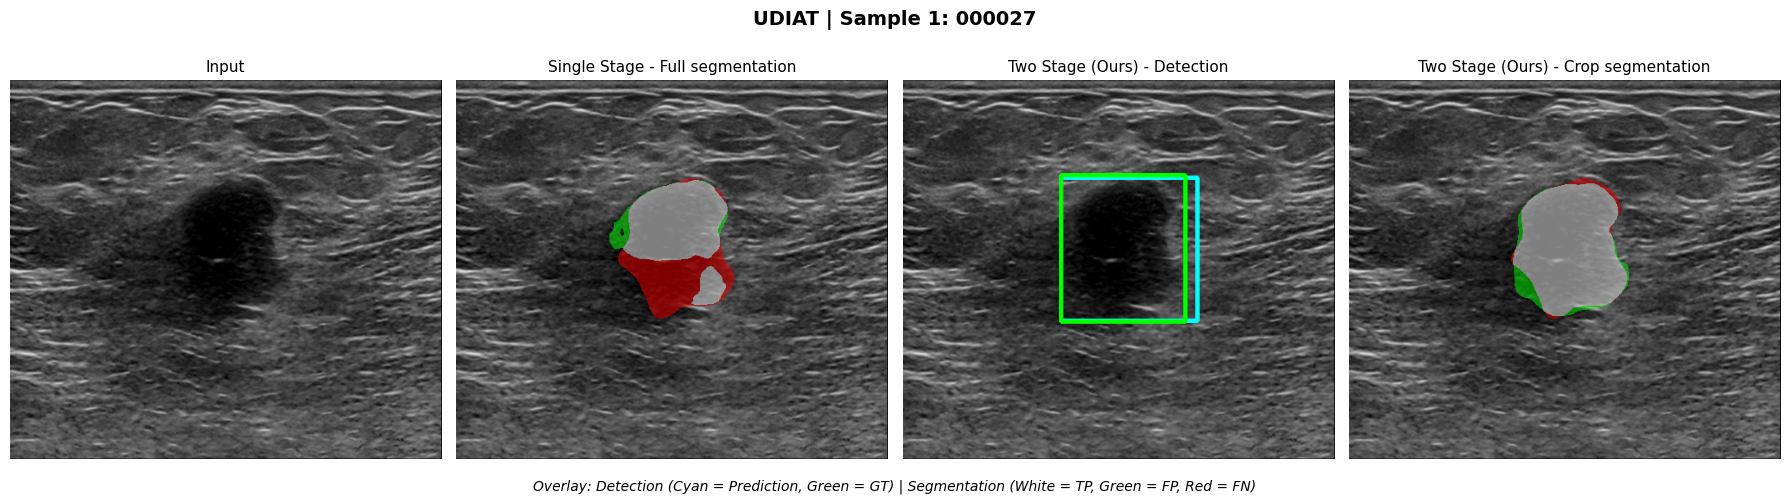

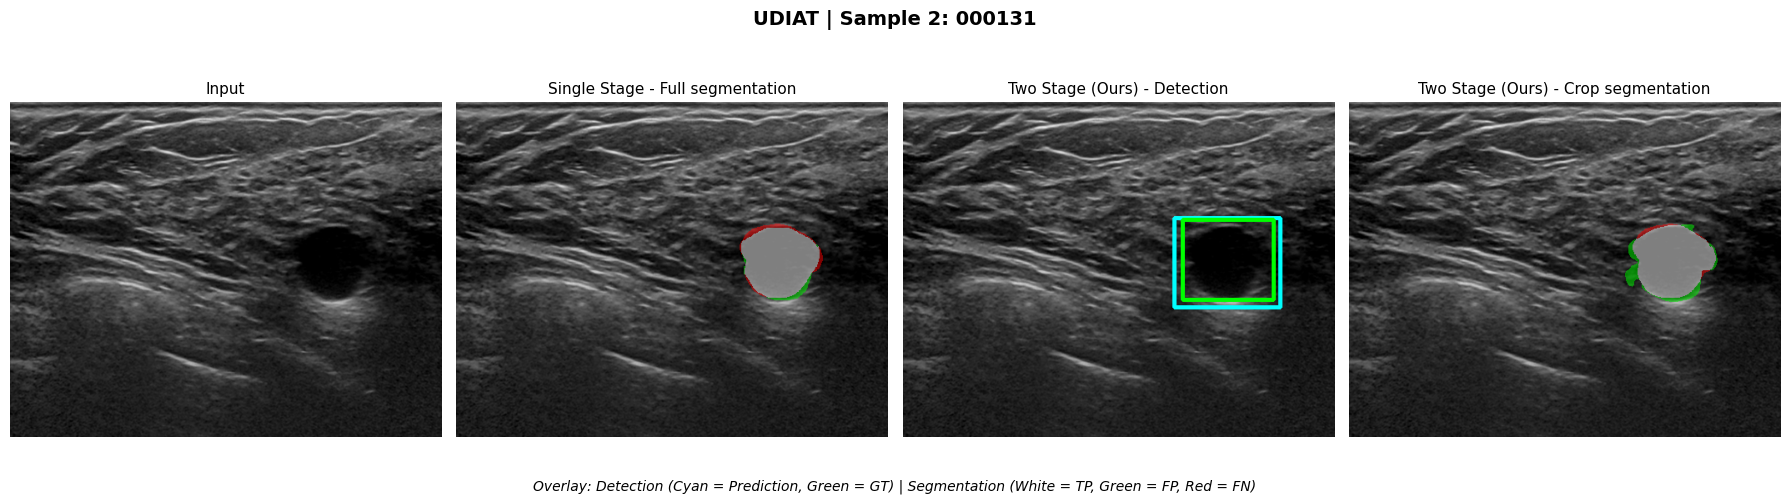

In [75]:
# ==========================================================
# Helper functions
# ==========================================================

def make_gt_overlay(img, gt, pred, alpha=0.5):
    """
    Overlay segmentation against GT.

    White : True Positive
    Green : False Positive
    Red   : False Negative
    """
    overlay = img.copy()

    tp = (gt == 1) & (pred == 1)
    fp = (gt == 0) & (pred == 1)
    fn = (gt == 1) & (pred == 0)

    colours = [
        (tp, (255, 255, 255)),
        (fp, (0, 255, 0)),
        (fn, (255, 0, 0)),
    ]

    for mask, colour in colours:
        overlay[mask] = (
            alpha * np.array(colour) +
            (1 - alpha) * overlay[mask]
        ).astype(np.uint8)

    return overlay


def colour_mask_overlay(img, mask, colour=(255, 255, 0), alpha=0.5):
    """
    Overlay predicted mask when GT is unavailable.
    """
    overlay = img.copy()
    mask = mask.astype(bool)

    overlay[mask] = (
        alpha * np.array(colour) +
        (1 - alpha) * overlay[mask]
    ).astype(np.uint8)

    return overlay


def predict_mask(model, image):
    """
    Predict segmentation mask and resize back
    to the original image resolution.
    """
    H, W = image.shape[:2]

    sample = aug(
        image=image,
        mask=np.zeros((H, W, 1), dtype=np.float32)
    )

    inp = torch.tensor(
        sample["image"].transpose(2, 0, 1),
        dtype=torch.float32
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        prob = model(inp).sigmoid().squeeze().cpu().numpy()

    pred = otsu_threshold(prob)

    pred = cv2.resize(
        pred,
        (W, H),
        interpolation=cv2.INTER_NEAREST
    )

    return pred


# ==========================================================
# Dataset
# ==========================================================

aug = get_validation_augmentation()

img_dir = os.path.join(DATA_DIR, dataset, "imgs")
gt_dir = os.path.join(DATA_DIR, dataset, "gts")

image_ids = sorted(
    Path(f).stem for f in glob(f"{img_dir}/*.*")
)

N_SAMPLES = min(5, len(image_ids))
image_ids = image_ids[:N_SAMPLES]

samples = []


# ==========================================================
# Run inference
# ==========================================================

for img_id in image_ids:

    img_path = os.path.join(img_dir, img_id + img_ext)
    gt_path = os.path.join(gt_dir, img_id + mask_ext)

    full_img = cv2.imread(img_path)
    full_rgb = cv2.cvtColor(full_img, cv2.COLOR_BGR2RGB)

    H, W = full_rgb.shape[:2]

    # ------------------------------------------------------
    # Single-stage segmentation
    # ------------------------------------------------------

    pred_full = predict_mask(seg_model, full_rgb)

    # ------------------------------------------------------
    # YOLO detection
    # ------------------------------------------------------

    results = yolo_model.predict(
        img_path,
        conf=YOLO_CONF,
        iou=YOLO_IOU,
        verbose=False
    )

    if len(results[0].boxes) == 0:
        print(f"Skipping {img_id}: no detection.")
        continue

    best_box = results[0].boxes[
        results[0].boxes.conf.argmax()
    ]

    x1, y1, x2, y2 = map(
        int,
        best_box.xyxy[0].tolist()
    )

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(W, x2)
    y2 = min(H, y2)

    detection_img = full_rgb.copy()

    cv2.rectangle(
        detection_img,
        (x1, y1),
        (x2, y2),
        (0, 255, 255),
        3
    )

    # ------------------------------------------------------
    # Crop segmentation
    # ------------------------------------------------------

    crop = full_rgb[y1:y2, x1:x2]

    pred_crop = predict_mask(
        seg_crop_model,
        crop
    )

    pred_two_stage = np.zeros((H, W), dtype=np.uint8)
    pred_two_stage[y1:y2, x1:x2] = pred_crop

    # ------------------------------------------------------
    # GT handling
    # ------------------------------------------------------

    has_gt = os.path.exists(gt_path)

    if has_gt:

        gt = cv2.imread(
            gt_path,
            cv2.IMREAD_GRAYSCALE
        )

        gt = (gt > 0).astype(np.uint8)

        full_display = make_gt_overlay(
            full_rgb,
            gt,
            pred_full
        )

        crop_display = make_gt_overlay(
            full_rgb,
            gt,
            pred_two_stage
        )
        
        gt_box = mask_to_yolo_box(
            Path(gt_path),
            (W, H)
        )

        if gt_box is not None:

            gx1, gy1, gx2, gy2 = yolo_to_xyxy(
                gt_box,
                W,
                H
            )
            # GT box (green)
            cv2.rectangle(
                detection_img,
                (gx1, gy1),
                (gx2, gy2),
                (0, 255, 0),
                3
            )
    else:

        full_display = colour_mask_overlay(
            full_rgb,
            pred_full
        )

        crop_display = colour_mask_overlay(
            full_rgb,
            pred_two_stage
        )

    samples.append({
        "id": img_id,
        "has_gt": has_gt,
        "images": [
            full_rgb,
            full_display,
            detection_img,
            crop_display,
        ]
    })


# ==========================================================
# Display
# ==========================================================

for i, sample in enumerate(samples):

    images = sample["images"]

    if sample["has_gt"]:
        titles = [
            "Input",
            "Single Stage - Full segmentation",
            "Two Stage (Ours) - Detection",
            "Two Stage (Ours) - Crop segmentation",
        ]
    else:
        titles = [
            "Input",
            "Single Stage - Full segmentation",
            "Two Stage (Ours) - Detection",
            "Two Stage (Ours) - Crop segmentation",
        ]

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(18, 5)
    )

    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img)
        ax.set_title(title, fontsize=11)
        ax.axis("off")

    if sample["has_gt"]:
        fig.text(
            0.5,
            0.02,
            "Overlay: Detection (Cyan = Prediction, Green = GT) | Segmentation (White = TP, Green = FP, Red = FN)",
            ha="center",
            fontsize=10,
            style="italic",
        )
    else:
        fig.text(
            0.5,
            0.02,
            "Mask: Detection (Cyan = Prediction) | Segmentation (Yellow = Prediction)",
            ha="center",
            fontsize=10,
            style="italic",
        )

    fig.suptitle(
        f"{dataset} | Sample {i+1}: {sample['id']}",
        fontsize=14,
        fontweight="bold",
    )

    plt.tight_layout(rect=[0, 0.04, 1, 0.95])
    plt.show()